### Instalar as bibliotecas necessárias:

Abra o terminal e execute os seguintes comandos:

In [1]:
pip install pandas pyarrow duckdb matplotlib

  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ------------- -------------------------- 3.4/9.8 MB 19.1 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.8 MB 22.4 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 22.1 MB/s  0:00:00
   ---------------------------------------- 0.0/27.9 MB ? eta -:--:--
   ----------- ---------------------------- 7.9/27.9 MB 39.0 MB/s eta 0:00:01
   ------------------------------- -------- 22.3/27.9 MB 55.0 MB/s eta 0:00:01
   ---------------------------------------- 27.9/27.9 MB 55.0 MB/s  0:00:00
   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   ---------------------------------------- 13.2/13.2 MB 75.5 MB/s  0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 9.3/9.3

### Baixar o conjunto de dados:

    Baixe um arquivo CSV grande (ex.: logs de navegação ou vendas) ou gere um conjunto de dados sintético usando Python:

In [2]:
import pandas as pd
import numpy as np

# Gerar dados sintéticos
data = {
    "UserID": np.random.randint(1, 1000, 1000000),
    "Timestamp": pd.date_range(start="2023-01-01", periods=1000000, freq="s"),
    "URLVisitada": [f"pagina_{i % 10}" for i in range(1000000)],
    "TempoSessao": np.random.randint(10, 300, 1000000)
}
df = pd.DataFrame(data)
df.to_csv("dados_logs.csv", index=False)


### Converter o CSV para formato colunar (Parquet):

    Use o Pandas para converter o CSV em um arquivo Parquet:

In [3]:
import pandas as pd

# Ler o CSV
df = pd.read_csv("dados_logs.csv")

# Salvar como Parquet
df.to_parquet("dados_logs.parquet", engine="pyarrow")

### Parte 2: Consultas Analíticas

    Carregar o arquivo Parquet com DuckDB:
        DuckDB é uma ferramenta leve que suporta consultas SQL em arquivos Parquet. Execute o seguinte código:

In [4]:
import duckdb

# Conectar ao DuckDB
con = duckdb.connect()

# Carregar o arquivo Parquet
con.execute("CREATE TABLE logs AS SELECT * FROM read_parquet('dados_logs.parquet')")

### Executar consultas analíticas:

    Execute consultas SQL para explorar os dados:

In [5]:
# Contagem de visitas por página
result = con.execute("""
    SELECT URLVisitada, COUNT(*) AS TotalVisitas
    FROM logs
    GROUP BY URLVisitada
    ORDER BY TotalVisitas DESC
""").fetchall()

print(result)

# Média de tempo de sessão por usuário
result = con.execute("""
    SELECT UserID, AVG(TempoSessao) AS MediaTempoSessao
    FROM logs
    GROUP BY UserID
    ORDER BY MediaTempoSessao DESC
""").fetchall()

print(result)

[('pagina_1', 100000), ('pagina_4', 100000), ('pagina_3', 100000), ('pagina_6', 100000), ('pagina_8', 100000), ('pagina_0', 100000), ('pagina_2', 100000), ('pagina_7', 100000), ('pagina_9', 100000), ('pagina_5', 100000)]
[(562, 162.9078014184397), (864, 161.74747474747474), (655, 161.48136958710978), (798, 161.3918650793651), (450, 161.3235887096774), (167, 161.29855371900825), (637, 161.20402298850576), (485, 161.1294498381877), (836, 161.125), (569, 160.76111685625645), (456, 160.71557788944725), (703, 160.5746561886051), (580, 160.5096153846154), (537, 160.4633165829146), (888, 160.3615763546798), (72, 160.17773237997957), (512, 160.1051051051051), (458, 160.0319361277445), (683, 159.99187817258883), (394, 159.95954356846474), (227, 159.94509803921568), (210, 159.93279022403257), (883, 159.79684601113172), (399, 159.77866400797606), (8, 159.77698574338086), (520, 159.63119834710744), (877, 159.57411067193675), (959, 159.56868395773296), (283, 159.37824351297405), (169, 159.365612648

### Comparar desempenho entre CSV e Parquet:

    Compare o tempo de execução das mesmas consultas em um arquivo CSV e no arquivo Parquet:

In [8]:
import time

# Consulta no CSV
start_time = time.time()
df_csv = pd.read_csv("dados_logs.csv")
df_csv.groupby("URLVisitada").size().reset_index(name="TotalVisitas")
print(f"Tempo CSV: {time.time() - start_time}")

# Consulta no Parquet
start_time = time.time()
df_parquet = pd.read_parquet("dados_logs.parquet")
df_parquet.groupby("URLVisitada").size().reset_index(name="TotalVisitas")
print(f"Tempo Parquet: {time.time() - start_time}")

Tempo CSV: 0.7685048580169678
Tempo Parquet: 0.05183291435241699


### Parte 3: Análise dos Resultados

    Discussão em sala:
        Quais foram as diferenças de desempenho entre o CSV e o Parquet?
        Por que o formato colunar (Parquet) é mais eficiente para consultas analíticas?
    Visualização dos dados:
        Use uma ferramenta gráfica (ex.: Matplotlib ou Seaborn) para visualizar os resultados das consultas:

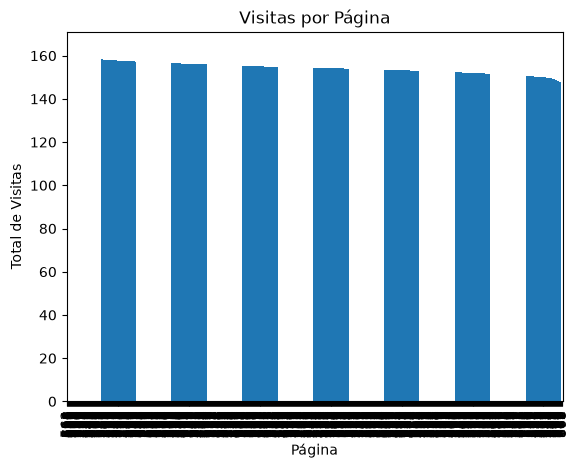

In [9]:
import matplotlib.pyplot as plt

# Visualizar contagem de visitas por página
df_result = pd.DataFrame(result, columns=["URLVisitada", "TotalVisitas"])
df_result.plot(kind="bar", x="URLVisitada", y="TotalVisitas", legend=False)
plt.title("Visitas por Página")
plt.xlabel("Página")
plt.ylabel("Total de Visitas")
plt.show()

### Conclusão

    Resumo:
        Bancos de dados colunares, como o Amazon Redshift, utilizam formatos semelhantes ao Parquet para otimizar consultas analíticas.
        O formato colunar reduz o tempo de leitura e melhora o desempenho em grandes volumes de dados.
    Reflexão:
        Em quais cenários você usaria um banco de dados colunar em vez de um relacional?